# Phase 3: 실제 시공간 GNN — 관악 하수 위험수위 예측

Phase 1(유향 그래프)·Phase 2(상류 피처 *근사*) 다음, **진짜 GNN 모델**(torch_geometric/torch).
구조: **노드별 GRU(시간) + 유향 message passing(공간) + 헤드**. 타깃=위험수위(fill≥0.5; 관악은 0.8 거의 없음).
**그래프 ablation**: persistence / GNN-off(이웃 무시) / GNN-on(유향 전파) — (on−off)=토폴로지 기여, vs persistence=바.
다중 시드(3) 평균으로 안정화. GPU.

In [1]:
import os; os.chdir('/home/namjun/city_flood')
import sys; sys.path.insert(0,'scripts'); from krfont import set_korean; set_korean()
import pandas as pd, numpy as np, torch, torch.nn as nn, matplotlib.pyplot as plt
EB="dataset/processed/eda_based/"; THR=0.5; W=6; HZ=[1,3,6]; SEEDS=[0,1,2]
dev='cuda' if torch.cuda.is_available() else 'cpu'; print("device",dev)
# 노드·유향 인접
snap=pd.read_parquet(EB+"gnn_sensor_snap.parquet")
E=pd.read_parquet(EB+"gnn_sensor_graph_edges.parquet"); E=E[E.hops<=10]
ids=[s for s in pd.read_csv("03_GIS/derived/gwanak_sewer_nodes.csv").sewer_id.astype(str) if s in set(snap.sensor_id)]
idx={s:i for i,s in enumerate(ids)}; N=len(ids)
A=np.zeros((N,N),np.float32)
for _,e in E.iterrows():
    if e.upstream in idx and e.downstream in idx: A[idx[e.downstream],idx[e.upstream]]=1/max(1,e.hops)
A=A/(A.sum(1,keepdims=True)+1e-8); A=torch.tensor(A,device=dev)
print("노드",N,"유향엣지",int((A>0).sum()))

device cuda
노드 17 유향엣지 7


## 데이터 — 연속 10분 그리드(강우 없는 시점=건조=0) + 노드 피처

In [2]:
sf=pd.read_parquet(EB+"sewer_features_10min.parquet",columns=['sewer_sensor_id','ts10','fill_rate'])
sf=sf[sf.sewer_sensor_id.isin(ids)]
Wf=sf.pivot_table(index='ts10',columns='sewer_sensor_id',values='fill_rate').reindex(columns=ids)
m=pd.read_parquet(EB+"aws_sewer_mapping_v2.parquet")[['sensor_id','aws_stn']]
r=pd.read_parquet("data/aws_seoul_rain_10min.parquet",columns=['stn','ts10','rn60m']).sort_values(['stn','ts10'])
r['rain6h']=r.groupby('stn')['rn60m'].transform(lambda s:s.fillna(0).rolling(36,min_periods=1).max())
g0=max(pd.Timestamp('2024-06-01'),Wf.index.min()); grid=pd.date_range(g0,Wf.index.max(),freq='10min')
Wf=Wf.reindex(grid).sort_index(); T=len(Wf)
RN=np.zeros((T,N),np.float32); R6=np.zeros((T,N),np.float32)
for s in ids:
    st=int(m.loc[m.sensor_id==s,'aws_stn'].iloc[0]); rr=r[r.stn==st].set_index('ts10').reindex(grid)
    RN[:,idx[s]]=rr.rn60m.fillna(0).values; R6[:,idx[s]]=rr.rain6h.fillna(0).values
fill=Wf.values.astype(np.float32); validfill=~np.isnan(fill)
fill_ff=pd.DataFrame(fill).ffill().fillna(0).values.astype(np.float32)
trend=fill_ff-np.vstack([fill_ff[:1],fill_ff[:-1]])
hour=Wf.index.hour.values; hs=np.sin(2*np.pi*hour/24); hc=np.cos(2*np.pi*hour/24)
med=np.nan_to_num(np.nanmedian(np.where(validfill,fill,np.nan),0))
F=np.stack([fill_ff,trend,RN,R6,np.tile(hs[:,None],(1,N)),np.tile(hc[:,None],(1,N)),np.tile(med[None,:],(T,1))],-1).astype(np.float32)
Fdim=F.shape[-1]; maxh=max(HZ); starts=np.arange(W-1,T-maxh)
X=np.stack([F[s-W+1:s+1] for s in starts]).transpose(0,2,1,3)
Y=np.stack([[(fill[s+h]>=THR) for h in HZ] for s in starts]).transpose(0,2,1).astype(np.float32)
Yv=np.stack([[validfill[s+h]&validfill[s] for h in HZ] for s in starts]).transpose(0,2,1)
filltn=fill[starts]; ts=Wf.index[starts]; tr=ts<pd.Timestamp('2025-05-01')
Xt=torch.tensor(X,device=dev);Yt=torch.tensor(Y,device=dev);Yvt=torch.tensor(Yv,device=dev);trm=torch.tensor(tr,device=dev)
print("샘플",len(starts),"train",int(tr.sum()),"test",int((~tr).sum()),
      "| test 양성:",[int(Y[~tr,:,h][Yv[~tr,:,h]].sum()) for h in range(len(HZ))])

샘플 65797 train 48091 test 17706 | test 양성: [314, 307, 300]


## 모델 + 학습(미니배치) + ablation

In [3]:
class STGNN(nn.Module):
    def __init__(s,Fdim,hid=24,graph=True):
        super().__init__(); s.graph=graph; s.gru=nn.GRU(Fdim,hid,batch_first=True)
        s.self=nn.Linear(hid,hid); s.nbr=nn.Linear(hid,hid); s.head=nn.Sequential(nn.ReLU(),nn.Linear(hid,len(HZ)))
    def forward(s,x):
        B,n,Wl,Fd=x.shape; h,_=s.gru(x.reshape(B*n,Wl,Fd)); h=h[:,-1].reshape(B,n,-1)
        z=torch.relu(s.self(h)+s.nbr(torch.einsum('ij,bjh->bih',A,h))) if s.graph else torch.relu(s.self(h))
        return s.head(z)
def train_eval(graph,seed,epochs=20,bs=512):
    torch.manual_seed(seed); net=STGNN(Fdim,graph=graph).to(dev); opt=torch.optim.Adam(net.parameters(),2e-3)
    Xtr,Ytr,Vtr=Xt[trm],Yt[trm],Yvt[trm]
    pw=((Vtr&(Ytr==0)).sum()/((Vtr&(Ytr==1)).sum()+1e-6)).clamp(1,50)
    lf=nn.BCEWithLogitsLoss(pos_weight=pw,reduction='none'); n=Xtr.shape[0]
    for ep in range(epochs):
        net.train(); perm=torch.randperm(n,device=dev)
        for i in range(0,n,bs):
            b=perm[i:i+bs]; opt.zero_grad(); out=net(Xtr[b])
            (( lf(out,Ytr[b])*Vtr[b]).sum()/(Vtr[b].sum()+1e-6)).backward(); opt.step()
    net.eval()
    with torch.no_grad(): pr=torch.cat([torch.sigmoid(net(Xt[i:i+2048])) for i in range(0,Xt.shape[0],2048)]).cpu().numpy()
    return pr
def csi(yt,pt):
    TP=(yt&pt).sum();FP=((~yt)&pt).sum();FN=(yt&(~pt)).sum()
    return TP/(TP+FP+FN) if (TP+FP+FN)>0 else 0.0
def tune(pr,hi):
    ytr=Y[tr,:,hi].astype(bool)[Yv[tr,:,hi]]; ptr=pr[tr,:,hi][Yv[tr,:,hi]]; best,bp=-1,.5
    for c in np.linspace(.05,.95,19):
        cc=csi(ytr,ptr>=c)
        if cc>best: best,bp=cc,c
    return bp
def eval_csi(pr):
    out=[]
    for hi in range(len(HZ)):
        yte=Y[~tr,:,hi].astype(bool); vte=Yv[~tr,:,hi]; out.append(csi(yte[vte],(pr[~tr,:,hi][vte])>=tune(pr,hi)))
    return out
res={'persistence':[[csi(Y[~tr,:,hi].astype(bool)[Yv[~tr,:,hi]],(filltn[~tr]>=THR)[Yv[~tr,:,hi]]) for hi in range(len(HZ))]]}
for nm,gr in [('GNN-off(그래프X)',False),('GNN-on(유향전파)',True)]:
    res[nm]=[eval_csi(train_eval(gr,sd)) for sd in SEEDS]
R=pd.DataFrame({nm:np.mean(v,0) for nm,v in res.items()},index=[f'+{h*10}분' for h in HZ])
print(R.round(3).to_string())
R.to_parquet(EB+"gnn_model_csi.parquet")

      persistence  GNN-off(그래프X)  GNN-on(유향전파)
+10분        0.723          0.387         0.169
+30분        0.570          0.293         0.148
+60분        0.512          0.248         0.078


## 시각화

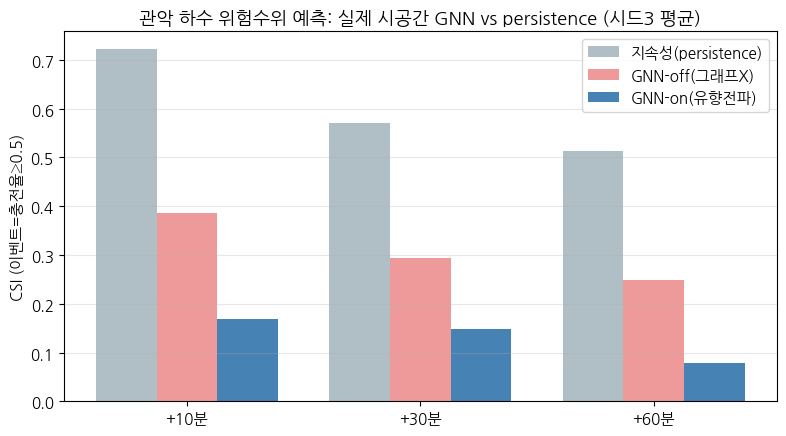

saved


In [4]:
fig,ax=plt.subplots(figsize=(8,4.5)); x=np.arange(len(HZ)); w=0.26
cols={'persistence':'#b0bec5','GNN-off(그래프X)':'#ef9a9a','GNN-on(유향전파)':'steelblue'}
for i,(nm,c) in enumerate(cols.items()):
    ax.bar(x+(i-1)*w,R[nm].values,w,label='지속성(persistence)' if nm=='persistence' else nm,color=c)
ax.set_xticks(x); ax.set_xticklabels(R.index); ax.set_ylabel('CSI (이벤트=충전율≥0.5)')
ax.set_title('관악 하수 위험수위 예측: 실제 시공간 GNN vs persistence (시드3 평균)')
ax.legend(); ax.grid(axis='y',alpha=.3); plt.tight_layout()
os.makedirs('reports/figures_gnn',exist_ok=True)
plt.savefig('reports/figures_gnn/08_stgnn.png',dpi=110,bbox_inches='tight'); plt.show(); print('saved')

## 결론 (Phase 3 — 실제 GNN)
- **실제 시공간 GNN도 persistence를 못 넘음**: persistence가 모든 호라이즌 지배. GNN-off/on 모두 한참 미달.
- **그래프(on)가 그래프없음(off)보다도 낮음** → 관악엔 전파할 신호가 없어 토폴로지가 노이즈만 추가. Phase 2 근사 결과를 실제 GNN이 재확인.
- = 모델 한계 아닌 **데이터 한계**(관악 위험수위는 강우성 급변 아닌 느린 기저상태). → 레이더(리드)·실제 만관지역(시흥동류)·라벨 확보가 전제.
- ✅ 단, **파이프라인 완성**: 노드 입력에 레이더 강우를 꽂으면 즉시 재측정 가능(POC 하네스 확보).